# Order Book Signals on Bond & Equity Calendar Spreads

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import polars.selectors as cs
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from plotnine import *
from plotnine.themes import theme_bw

from src.utils import (
    connect_snowflake,
    create_snowpark_session,
    retrieve_polars_from_snowpark,
    unpack_kwargs,
    unpack_kwargs_for_agg,
    read_table,
    parse_security,
    build_contract_calendar,
    add_roll_window,
    add_microstructure_signals,
    acf_by_security,
    ljungbox_by_security,
    newey_west_maxlags,
)
from snowflake.snowpark import functions as F
from snowflake.snowpark.window import Window
from functools import reduce
import operator

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)
print('polars', pl.__version__)

In [ ]:
DB     = 'LISTED_INTERN_PROJECT'
SCHEMA = 'PROJECT_5'
TABLES = ['BINNED_DATA', 'QCODE_MAPPING', 'SECURITY_META']

snowflake_conn = connect_snowflake('../.env')
snowpark = create_snowpark_session('../.env')
print('Connected.')

In [ ]:
# Data subset: Years 2021-2025 (narrowed to the chosen years in the preprocessing step).

BINNED_COLS = [
    'QCODE', 'SECURITY', 'BIN_START_TIME', 'PUBLICATION_DATE',
    'BID_SIZE_START', 'ASK_SIZE_START', 'BID_START', 'ASK_START',
    'VOLUME', 'SIGNED_VOLUME',
]
QCODE_COLS    = ['QCODE', 'BBG_CODE', 'YELLOW_KEY', 'DELIVERY', 'IS_CONVENTION_BUY_NEAR']
SEC_META_COLS = ['SECURITY', 'LAST_TRADE_DATE', 'FIRST_NOTICE_DATE']

qmap     = read_table(snowpark, DB, SCHEMA, 'QCODE_MAPPING', QCODE_COLS)
sec_meta = read_table(snowpark, DB, SCHEMA, 'SECURITY_META', SEC_META_COLS)

phys_qcodes = qmap.filter(pl.col('delivery') == 'Phys')['qcode'].unique().to_list()
cash_qcodes = qmap.filter(pl.col('delivery') == 'Cash')['qcode'].unique().to_list()
subset_qcodes = phys_qcodes + cash_qcodes
print(f'Phys qcodes : {phys_qcodes}')
print(f'Cash qcodes : {cash_qcodes}')

# BBG_CODE + YELLOW_KEY — used to construct the spread filter.
subset_products = (
    qmap.filter(pl.col('qcode').is_in(subset_qcodes))
    .select('bbg_code', 'yellow_key')
    .unique()
)

fqn_binned = f'{DB}.{SCHEMA}.BINNED_DATA'

# Futures: QCODE in our subset AND SECURITY has no slash (LIKE '%/%' negated).
futures_filter = (
    F.col('QCODE').isin(subset_qcodes) &
    ~F.col('SECURITY').like('%/%')
)

# Spreads: SECURITY matches pattern  {BBG_CODE}.../{...} {YELLOW_KEY}.
# Using Snowflake LIKE: '%' = zero-or-more wildcard characters.

spread_clauses = [
    F.col('SECURITY').like(f'{row["bbg_code"]}%/% {row["yellow_key"]}')
    for row in subset_products.iter_rows(named=True)
]
spread_filter = reduce(operator.or_, spread_clauses)

snow_binned = (
    snowpark.table(fqn_binned)
    .select(*BINNED_COLS)
    .filter(futures_filter | spread_filter)
)
binned = retrieve_polars_from_snowpark(snow_binned)

n_fut = binned.filter(~pl.col('security').str.contains('/')).height
n_spr = binned.filter(pl.col('security').str.contains('/')).height
print(f'binned   : {binned.shape}  (futures: {n_fut:,}  |  spreads: {n_spr:,})')
print(f'qmap     : {qmap.shape}')
print(f'sec_meta : {sec_meta.shape}')

## Preprocessing
Outputs:
- `df_cs` — filtered calendar spreads only.
- `df_combined` — filtered calendar spreads **and** filtered futures.

In [ ]:
# Step 1: merge BINNED_DATA with QCODE_MAPPING on QCODE.
# Spreads pulled via the name-pattern filter may have QCODEs outside subset_qcodes,
# so their bbg_code / yellow_key / delivery / is_convention_buy_near will be null here.
data = binned.join(qmap, on='qcode', how='left')

# Step 2: parse SECURITY -> is_spread, near/far identifiers, meta_key.
data = parse_security(data, col='security')

data.head()

# Steps 3-4: build the per-future roll calendar (target date + own/previous roll windows).
calendar = build_contract_calendar(sec_meta, qmap, roll_days=10)

# Drop qmap's 'delivery' before joining the calendar so the calendar's 'delivery'
# (correctly resolved from BBG_CODE+YELLOW_KEY for every security) is the sole authority.
data = data.drop('delivery')
data = data.join(
    calendar.rename({'security': 'meta_key'}),
    on='meta_key',
    how='left',
)

# Step 5: trading date from PUBLICATION_DATE (BIN_START_TIME is time-only, not a date).
data = data.with_columns(date=pl.col('publication_date').cast(pl.Date))

# Step 6: keep rows whose trading date (PUBLICATION_DATE year) is 2021-2025 inclusive.
# These years feed the chronological OOS split downstream:
#   train = 2021-2023, validation = 2024, test = 2025.
data = data.filter(pl.col('publication_date').dt.year().is_in([2021, 2022, 2023, 2024, 2025]))

n_spread = data.filter(pl.col('is_spread')).height
print(f'rows: {data.height:,}  |  spread rows: {n_spread:,}  |  future rows: {data.height - n_spread:,}')
data.select(
    'security', 'is_spread', 'near_identifier', 'far_identifier', 'meta_key',
    'delivery', 'target_date', 'roll_start', 'roll_end', 'prev_roll_start', 'prev_roll_end',
).head()

In [ ]:
# A bin sits inside a [start, end] window (inclusive). Null bounds (missing metadata) -> False.
def _in_window(start: str, end: str) -> pl.Expr:
    return pl.col('date').is_between(pl.col(start), pl.col(end), closed='both').fill_null(False)

in_own_roll  = _in_window('roll_start', 'roll_end')
in_prev_roll = _in_window('prev_roll_start', 'prev_roll_end')

# Calendar spreads: own (near-leg) roll period only.
df_cs = data.filter(pl.col('is_spread') & in_own_roll)

# Futures: own roll period OR previous contract's roll period.
df_fut = data.filter(~pl.col('is_spread') & (in_own_roll | in_prev_roll))

# Combined: filtered spreads + filtered futures (aligned schema via vertical concat).
df_combined = pl.concat([df_cs, df_fut], how='vertical')

print(f'df_cs       : {df_cs.shape}')
print(f'df_fut      : {df_fut.shape}')
print(f'df_combined : {df_combined.shape}')
df_cs.head()

In [ ]:
# roll period is when daily volume exceeds 25% of daily max for same security

daily_volume = df_cs.group_by('security', 'date').agg(daily_vol=pl.col('volume').sum())

max_volume = daily_volume.group_by('security').agg(max_daily_vol=pl.col('daily_vol').max())

df_cs = df_cs.join(daily_volume, on=['security', 'date'], how='left')
df_cs = df_cs.join(max_volume, on='security', how='left')
df_cs = df_cs.with_columns(
    is_roll_period=(pl.col('daily_vol') >= 0.25 * pl.col('max_daily_vol'))
).drop(['daily_vol', 'max_daily_vol'])

df_cs = df_cs.filter(pl.col('is_roll_period'))

## Signal Generation

Using the per-bin `*_START` quotes:

| Signal | Definition |
|---|---|
| $P_t$ (`mid_price`) | $(\text{BID\_START} + \text{ASK\_START})/2$ |
| $\Delta P_t$ (`delta_p`) | $P_t - P_{t-1}$ (within session) |
| $OBI_t$ (`obi`) | $\text{BID\_SIZE\_START} - \text{ASK\_SIZE\_START}$ |
| $\Delta L_t^b$ (`delta_lb`) | $Q_t^b-Q_{t-1}^b$ if $P_t^b=P_{t-1}^b$; $\;Q_t^b$ if $P_t^b>P_{t-1}^b$; $\;-Q_{t-1}^b$ if $P_t^b<P_{t-1}^b$ |
| $\Delta L_t^a$ (`delta_la`) | mirror of the bid (an ask *improvement* is a price **decrease**) |
| $OBC_t$ (`ofi`) | $\Delta L_t^b - \Delta L_t^a$  (order-flow imbalance) |
| $STV_t$ (`stv`) | `SIGNED_VOLUME` (dataset); empty bins → 0 |
| $NOI_t$ (`noi`) | $OBC_t - STV_t$ |

A `date` session key is added automatically. Result is saved to **`df_signals`**.

In [ ]:
# --- Signal generation (partitioned by SESSION [security, date], ordered by time) ----
df_signals = add_microstructure_signals(df_cs, security_col='security', time_col='bin_start_time')

n_sessions = df_signals.select(['security', 'date']).n_unique()
print(f'df_signals: {df_signals.shape}  ({df_signals["security"].n_unique()} spreads, {n_sessions} sessions)')
df_signals.select(
    'security', 'date', 'bin_start_time', 'mid_price', 'delta_p', 'obi',
    'delta_lb', 'delta_la', 'ofi', 'stv', 'noi', 'days_before'
).describe()

In [ ]:
# --- Normalise signals --------------------------------------------------------
# Normalised values overwrite the raw columns so downstream sections (H1, H2, H3)
# use normalised signals automatically.
#
# All five expressions are evaluated against the INPUT state of df_signals in the
# final with_columns call — Polars never sees intermediate results within the same
# call.  This means pl.col('ofi') in the NOI denominator is the PRE-Z-SCORE raw OFI.
#
# fill_nan(None) converts floating-point 0/0 = NaN to null for inactive bins rather
# than propagating NaN into the regression.

ROLL_WIN = 60   # rolling-window length for OFI z-score (bins, within each session)
SESSION  = ['security', 'date']

# 1. Tick size per BBG_CODE: minimum strictly-positive |delta_p|.
tick_sizes = (
    df_signals
    .filter(pl.col('delta_p').abs() > 10e-6)  # filter out zero and near-zero price changes to avoid noise/tick size confusion)
    .group_by('bbg_code')
    .agg(_tick=pl.col('delta_p').abs().min())
)
df_signals = df_signals.join(tick_sizes, on='bbg_code', how='left')

# Pre-compute rolling OFI mean and std within each session.
# df_signals is already sorted by [security, date, bin_start_time].
df_signals = df_signals.with_columns(
    _ofi_mu=pl.col('ofi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _ofi_sd=pl.col('ofi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)

# Apply all five normalisations in a single pass.
_vol = pl.col('volume').cast(pl.Float64)

df_signals = df_signals.with_columns(
    # 1. delta_p in ticks (per-BBG_CODE tick size).
    delta_p=(pl.col('delta_p') / pl.col('_tick')).fill_nan(None),
    # 2. OBI as fraction of total quoted size at the touch.
    obi=(pl.col('obi') / (pl.col('bid_size_start') + pl.col('ask_size_start'))).fill_nan(None),
    # 3. STV as signed square root of raw STV
    stv=(pl.col('stv').cast(pl.Float64).abs().sqrt() * pl.col('stv').sign()).fill_nan(None),
    # 4. OFI as rolling z-score within session.
    ofi=((pl.col('ofi') - pl.col('_ofi_mu')) / pl.col('_ofi_sd')).fill_nan(None),
    # 5. NOI as signed square root of raw NOI
    noi=(pl.col('noi').cast(pl.Float64).abs().sqrt() * pl.col('noi').sign()).fill_nan(None),
).drop(['_ofi_mu', '_ofi_sd'])


df_signals = df_signals.with_columns(
    _stv_mu=pl.col('stv').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _stv_sd=pl.col('stv').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_mu=pl.col('noi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_sd=pl.col('noi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)


df_signals = df_signals.with_columns(
    _stv_sd=pl.when(pl.col('_stv_sd') < 1e-6).then(pl.col('_stv_sd').filter(pl.col('_stv_sd') >= 1e-6).mean()).otherwise(pl.col('_stv_sd')),
    _noi_sd=pl.when(pl.col('_noi_sd') < 1e-6).then(pl.col('_noi_sd').filter(pl.col('_noi_sd') >= 1e-6).mean()).otherwise(pl.col('_noi_sd')),
)

# 3. STV and 5. NOI as rolling z-scores within session.
df_signals = df_signals.with_columns(
    stv=((pl.col('stv') - pl.col('_stv_mu')) / pl.col('_stv_sd')),
    noi=((pl.col('noi') - pl.col('_noi_mu')) / pl.col('_noi_sd')),
).drop(['_stv_mu', '_stv_sd', '_noi_mu', '_noi_sd'])

print(f'df_signals (normalised): {df_signals.shape}')
df_signals.select('security', 'date', 'bin_start_time', 'delta_p', 'obi', 'stv', 'ofi', 'noi').describe()

In [ ]:
# Metrics for measuring tick constrainedness

zero_pct = (df_signals
    .with_columns(is_change_small=(pl.col("delta_p").abs().cast(pl.Int32) <= 2) & (pl.col("delta_p").abs().cast(pl.Int32) != 5))
    .group_by("bbg_code")
    .agg((pl.col("is_change_small").mean() * 100))
    .sort('is_change_small')
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
)

spread_one_tick_pct = (df_signals
    .with_columns(is_one_tick=(pl.col("ask_start") - pl.col("bid_start"))//pl.col("_tick") <= 2)
    .group_by("bbg_code")
    .agg((pl.col("is_one_tick").mean() * 100))
    .sort('is_one_tick')
    .join(
        qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left'
    )
)

daily_volatility = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(daily_volatility=pl.col('delta_p').std())
    .filter(pl.col('daily_volatility') > 0)  # filter out zero-vol days to avoid division issues in tick-to-vol ratio
)

tick_to_volatility_ratio = (
    daily_volatility
    .group_by('bbg_code')
    .agg(tick_to_volatility=(1 / pl.col('daily_volatility')).mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('tick_to_volatility')
)

depth_to_trade_ratio = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(
        depth=(pl.col('bid_size_start') + pl.col('ask_size_start')).sum(),
        volume=pl.col('volume').sum()
    )
    .with_columns(depth_to_trade=pl.col('depth') / pl.col('volume'))
    .group_by('bbg_code')
    .agg(avg_depth_to_trade=pl.col('depth_to_trade').mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('avg_depth_to_trade')
)

print(f"Percentage of zeros: {zero_pct}%")
print(f"Percentage of one-tick spreads: {spread_one_tick_pct}%")
print(f"Average tick-to-volatility ratio: {tick_to_volatility_ratio}")
print(f"Average depth-to-trade ratio: {depth_to_trade_ratio}")

In [ ]:
# Curve group is tick-constrained if it exhibit all four characteristics

tick_constrained_bbg =['OE', 'XP', 'DU', 'IK', 'RX', 'QZ', 'FV', 'TU', 'VG', 'UB', 'OAT']


df_signals_tu = df_signals.filter(~pl.col('bbg_code').is_in(tick_constrained_bbg))
df_signals_tc = df_signals.filter(pl.col('bbg_code').is_in(tick_constrained_bbg))

df_signals_tc.describe()

## Out-of-Sample Framework — Chronological Split

The tick-unconstrained hypotheses (H1, H2, H3) are evaluated out-of-sample with a
**chronological split on the trading-data year**:

| Split | Years | Role |
|---|---|---|
| Train | 2021, 2022, 2023 | fit OLS coefficients; in-sample diagnostics (H1, parameter inference) |
| Validation | 2024 | out-of-sample generalisation check |
| Test | 2025 | held-out out-of-sample evaluation |

**No leakage by construction.** Every session key `[security, date]` lives entirely within one
calendar year, so all the within-session transforms computed *upstream* — the rolling z-scores
(OFI / STV / NOI) and the forward target shifts `.shift(-i).over(['security', 'date'])` — never
cross a train/val/test boundary. Forward targets are therefore built **before** the split, and
the split simply partitions already-completed rows by year.

H1 (autocorrelation / Ljung-Box) is an *in-sample* diagnostic, so it is run on the **train**
years only — no peeking at validation/test. To inspect the full-sample persistence instead,
swap `df_signals_tu_train` / `df_signals_tc_train` back to `df_signals_tu` / `df_signals_tc`.

In [ ]:
# === OOS framework: forward targets (within-session) THEN chronological split ===
import pandas as pd

SESSION     = ['security', 'date']
HORIZON     = 3
TRAIN_YEARS = [2021, 2022, 2023]
VAL_YEARS   = [2024]
TEST_YEARS  = [2025]
YEAR_LABEL  = {'train': '2021-2023', 'val': '2024', 'test': '2025'}

# Forward targets are shifted strictly WITHIN each [security, date] session, BEFORE the split.
# The last bin (resp. last HORIZON bins) of every session has a null forward target and is
# dropped per-model below, so a prediction never reaches across an overnight gap or a year
# boundary, and the chronological split introduces no look-ahead leakage.
forward_shifts = [pl.col('delta_p').shift(-i).over(SESSION) for i in range(1, HORIZON + 1)]

df_tu = (
    df_signals_tu
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(
        delta_p_fwd=pl.col('delta_p').shift(-1).over(SESSION),            # H3 1-step target
        delta_p_fwd_cumulative=reduce(operator.add, forward_shifts),      # H3 cumulative target
    )
    .with_columns(year=pl.col('date').dt.year())
)

# Train-only views for the in-sample H1 diagnostics (no peeking at val/test).
df_signals_tu_train = df_tu.filter(pl.col('year').is_in(TRAIN_YEARS))
df_signals_tc_train = df_signals_tc.filter(pl.col('date').dt.year().is_in(TRAIN_YEARS))


def make_splits(df, feature_cols, target_col):
    """Partition `df` into train/val/test by trading-data year, returning
    {split: (y, X_with_const)} as pandas with null rows dropped within each split."""
    splits = {}
    for name, years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
        pdf = (
            df.filter(pl.col('year').is_in(years))
              .select([target_col, *feature_cols])
              .drop_nulls()
              .to_pandas()
        )
        splits[name] = (pdf[target_col], sm.add_constant(pdf[feature_cols], has_constant='add'))
    return splits


def _metrics(y, y_pred):
    """R^2 (1 - SS_res/SS_tot vs. the split's own mean), RMSE and MAE."""
    resid  = y - y_pred
    ss_res = float((resid ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    return {
        'R2':   1 - ss_res / ss_tot if ss_tot > 0 else float('nan'),
        'RMSE': float(np.sqrt((resid ** 2).mean())),
        'MAE':  float(resid.abs().mean()),
    }


def fit_and_evaluate(target_col, feature_cols, label, extra_min_lags=0):
    """Fit OLS on TRAIN with Newey-West HAC SE (parameter inference), then predict on every
    split and report R^2 / RMSE / MAE for in-sample (train) vs out-of-sample (val/test).
    Returns (fitted_result, metrics_dataframe)."""
    splits = make_splits(df_tu, feature_cols, target_col)
    y_tr, X_tr = splits['train']
    T = len(y_tr)
    m = max(newey_west_maxlags(T), extra_min_lags)

    res = sm.OLS(y_tr, X_tr).fit(cov_type='HAC', cov_kwds={'maxlags': m})
    print(f'=== {label}:  {target_col} ~ {" + ".join(feature_cols)} ===')
    print(f'Train obs T = {T:,} | Newey-West maxlags m = {m}\n')
    print(res.summary())

    rows = []
    for name in ('train', 'val', 'test'):
        y, X = splits[name]
        row = {'split': name, 'years': YEAR_LABEL[name], 'n': len(y)}
        row.update(_metrics(y, res.predict(X)))
        rows.append(row)
    metrics = pd.DataFrame(rows)
    print('\nIn-sample (train) vs out-of-sample (val/test):')
    print(metrics.round(4).to_string(index=False))
    return res, metrics


for _name, _years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
    _n = df_tu.filter(pl.col('year').is_in(_years)).height
    print(f'{_name:<5} {YEAR_LABEL[_name]:>10} : {_n:>9,} rows')

## Hypothesis H1 — Autocorrelation & Persistence (Research Plan §5.1)

**H1:** both Signed Trade Volume ($STV_t$) and Net Order Inflow ($NOI_t$) exhibit significant,
slowly-decaying positive autocorrelation.

To keep the analysis **strictly intraday**, the ACF and Ljung-Box Q-test are computed
**per session `[SECURITY, DATE]`** (ordered by `BIN_START_TIME`) and then aggregated —
concatenating across day boundaries would inject spurious overnight/weekend lags. For each
$X \in \{STV_t, NOI_t\}$ we report the cross-sectional **mean ACF** out to lag $L=20$ (with the
$\pm 1.96/\sqrt{\bar n}$ white-noise band) and the **Ljung-Box** Q-test, validating H1 if the
null of no serial correlation is rejected at $p < 0.01$.

In [ ]:
# --- Sample ACF up to lag L = 12 (per SESSION [security, date], then averaged) ----
# In-sample diagnostic: TRAIN years only (df_signals_tu_train), no peeking at val/test.
L = 12
SESSION = ['security', 'date']
acf_results = {}

# Mean session length (used for the approximate white-noise band).
avg_n = df_signals_tu_train.group_by(SESSION).len()['len'].mean()
band = 1.96 / np.sqrt(avg_n)

for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tu_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')

In [ ]:
# ---  Ljung-Box Q-test (cumulative through lag 20), per SESSION [security, date] ----
# In-sample diagnostic: TRAIN years only (df_signals_tu_train).
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals_tu_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')

# --- H1 verdict --------------------------------------------------------------------
print('\n' + '=' * 60)
print('H1 verdict: significant, slowly-decaying POSITIVE autocorrelation')
print('is confirmed when the mean ACF stays positive above the band across')
print(f'lags and the Ljung-Box null is rejected (p<{ALPHA}) for ~all sessions.')

In [ ]:
# Tick-constrained groups: ACF on TRAIN years only (df_signals_tc_train).
for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tc_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')

In [ ]:
# Tick-constrained groups: Ljung-Box on TRAIN years only (df_signals_tc_train).
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals_tc_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')

# Tick-unconstrained curve groups

## Hypothesis H2 — Contemporaneous Price Impact (Research Plan §5.2)

Fit the contemporaneous regression

$$\Delta P_t = \beta_0 + \beta_1 STV_t + \beta_2 OFI_t + \beta_3 OBI_t + \epsilon_t$$

$NOI_t$ (`noi`) is **omitted** because $NOI_t = OFI_t - STV_t$ makes the three flow metrics
perfectly collinear.

**Out-of-sample protocol.** The model is fit on the **train** years (2021–2023) with
**Newey-West HAC** standard errors ($m = \lfloor 4 (T/100)^{2/9} \rfloor$) for coefficient
inference, then scored on **validation** (2024) and **test** (2025). Rows stay sorted by
`[security, date, bin_start_time]` so the HAC window operates mostly *within* an intraday session.
$R^2$, RMSE and MAE are reported per split so train→val→test degradation surfaces any overfitting.

**H2 is validated** if $\beta_1$ (STV) and $\beta_2$ (OFI) are positive and highly significant
($t > 2.5$) on train **and** the contemporaneous relationship persists out-of-sample
(comparable, positive val/test $R^2$).

In [41]:
# --- Model 1 (H2, contemporaneous): delta_p ~ stv + ofi + obi ----------------
# OLS fit on TRAIN (2021-2023) with Newey-West HAC SE for inference, then in-sample (train)
# vs out-of-sample (val 2024 / test 2025) R^2, RMSE and MAE. OFI kept, NOI omitted (collinear).
model_h2, metrics_h2 = fit_and_evaluate(
    target_col='delta_p',
    feature_cols=['stv', 'ofi', 'obi'],
    label='H2 contemporaneous',
)

=== H2 contemporaneous:  delta_p ~ stv + ofi + obi ===
Train obs T = 50,267 | Newey-West maxlags m = 15

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     446.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          3.41e-286
Time:                        14:03:55   Log-Likelihood:            -1.3992e+05
No. Observations:               50267   AIC:                         2.799e+05
Df Residuals:                   50263   BIC:                         2.799e+05
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

## Hypothesis H3 — Price Change Prediction (Research Plan §5.3)

Fit the **predictive** 1-step regression

$$\Delta P_{t+1} = \theta_0 + \theta_1 STV_t + \theta_2 NOI_t + \theta_3 OBI_t + \eta_{t+1}$$

and its cumulative $H$-step variant with target $\sum_{i=1}^{H}\Delta P_{t+i}$ ($H = 3$).

Both forward targets are built with `.shift(-i).over(['security', 'date'])` **before** the
chronological split, so the last (resp. last $H$) bin of every session has no target and is
dropped — a prediction never reaches across an overnight gap or a train/val/test year boundary.
$OFI_t$ is omitted (collinear with $NOI_t$ / $STV_t$).

**Out-of-sample protocol.** Fit on train (2021–2023) with Newey-West HAC errors — the cumulative
model floors the lag truncation at $H-1$ to cover the overlapping-target autocorrelation — then
report $R^2$ / RMSE / MAE on train vs validation (2024) and test (2025).

**H3 is validated** if $\theta_1$ / $\theta_2$ are significant on train **and** the model retains
predictive power out-of-sample (positive, non-trivial val/test $R^2$ rather than the near-zero
or negative $R^2$ that signals overfitting to in-sample noise).

In [42]:
# --- Model 2 (H3, 1-step predictive): delta_p_fwd ~ stv + noi + obi ----------
# Target delta_p_fwd = delta_p_{t+1}, shifted within each [security, date] session in the
# OOS-framework cell (before the split), so it is never the first bin of the following session
# and never crosses a year boundary. Fit on TRAIN with HAC SE; evaluate train vs val/test.
model_h3, metrics_h3 = fit_and_evaluate(
    target_col='delta_p_fwd',
    feature_cols=['stv', 'noi', 'obi'],
    label='H3 1-step predictive',
)

=== H3 1-step predictive:  delta_p_fwd ~ stv + noi + obi ===
Train obs T = 49,744 | Newey-West maxlags m = 15

                            OLS Regression Results                            
Dep. Variable:            delta_p_fwd   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     271.5
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          8.11e-175
Time:                        14:03:56   Log-Likelihood:            -1.3937e+05
No. Observations:               49744   AIC:                         2.788e+05
Df Residuals:                   49740   BIC:                         2.788e+05
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------

In [43]:
# --- Model 3 (H3, multi-step cumulative): delta_p_fwd_cumulative ~ stv + noi + obi ----
# Target = sum of delta_p over the next HORIZON bins, shifted within each [security, date]
# session in the OOS-framework cell (before the split); nulls in the final HORIZON bins are
# dropped per split. HAC maxlags floored at HORIZON-1 to cover the overlapping-target structure.
model_h3_multi, metrics_h3_multi = fit_and_evaluate(
    target_col='delta_p_fwd_cumulative',
    feature_cols=['stv', 'noi', 'obi'],
    label=f'H3 {HORIZON}-step cumulative',
    extra_min_lags=HORIZON - 1,
)

=== H3 3-step cumulative:  delta_p_fwd_cumulative ~ stv + noi + obi ===
Train obs T = 48,602 | Newey-West maxlags m = 15

                              OLS Regression Results                              
Dep. Variable:     delta_p_fwd_cumulative   R-squared:                       0.015
Model:                                OLS   Adj. R-squared:                  0.014
Method:                     Least Squares   F-statistic:                     148.7
Date:                    Wed, 10 Jun 2026   Prob (F-statistic):           6.76e-96
Time:                            14:03:56   Log-Likelihood:            -1.6014e+05
No. Observations:                   48602   AIC:                         3.203e+05
Df Residuals:                       48598   BIC:                         3.203e+05
Df Model:                               3                                         
Covariance Type:                      HAC                                         
                 coef    std err          z     

## Out-of-Sample Comparison — H2 / H3 / H3-cumulative

Side-by-side $R^2$ / RMSE / MAE across the three linear models and the three chronological
splits. The diagnostic for **overfitting** is the train→validation→test trajectory: a model
that has learned genuine structure holds a comparable, positive $R^2$ out-of-sample, whereas a
model fitting in-sample noise collapses to a near-zero or negative OOS $R^2$ while its RMSE/MAE
rise.

In [44]:
# --- Combined overfitting comparison across the three models ----------------
summary = pd.concat([
    metrics_h2.assign(model='H2 contemporaneous'),
    metrics_h3.assign(model='H3 1-step'),
    metrics_h3_multi.assign(model=f'H3 {HORIZON}-step cumulative'),
], ignore_index=True)

print('Full metrics (long format):')
print(summary[['model', 'split', 'years', 'n', 'R2', 'RMSE', 'MAE']].round(4).to_string(index=False))

# Wide R^2 view — the train -> val -> test trajectory is the overfitting signal.
r2_wide = (
    summary.pivot(index='model', columns='split', values='R2')[['train', 'val', 'test']]
    .rename(columns={'train': 'R2_train', 'val': 'R2_val', 'test': 'R2_test'})
)
print('\nR^2 by split (train = in-sample, val & test = out-of-sample):')
print(r2_wide.round(4).to_string())

summary

Full metrics (long format):
               model split     years     n     R2    RMSE    MAE
  H2 contemporaneous train 2021-2023 50267 0.0735  3.9143 1.4629
  H2 contemporaneous   val      2024 15990 0.0495  6.4344 2.0838
  H2 contemporaneous  test      2025 15670 0.0652  5.1288 1.7700
           H3 1-step train 2021-2023 49744 0.0249  3.9863 1.5083
           H3 1-step   val      2024 15811 0.0131  6.5190 2.1445
           H3 1-step  test      2025 15493 0.0215  5.1884 1.8025
H3 3-step cumulative train 2021-2023 48602 0.0145  6.5269 2.5117
H3 3-step cumulative   val      2024 15451 0.0048 10.8914 3.5544
H3 3-step cumulative  test      2025 15139 0.0089  9.0888 2.9950

R^2 by split (train = in-sample, val & test = out-of-sample):
split                 R2_train  R2_val  R2_test
model                                          
H2 contemporaneous      0.0735  0.0495   0.0652
H3 1-step               0.0249  0.0131   0.0215
H3 3-step cumulative    0.0145  0.0048   0.0089


,split,years,n,R2,RMSE,MAE,model
0,train,2021-2023,50267,0.073506,3.914322,1.462914,H2 contemporaneous
1,val,2024,15990,0.049529,6.434401,2.083832,H2 contemporaneous
2,test,2025,15670,0.065157,5.128843,1.769956,H2 contemporaneous
3,train,2021-2023,49744,0.024940,3.986270,1.508346,H3 1-step
4,val,2024,15811,0.013146,6.518958,2.144547,H3 1-step
5,test,2025,15493,0.021518,5.188409,1.802515,H3 1-step
6,train,2021-2023,48602,0.014517,6.526936,2.511694,H3 3-step cumulative
7,val,2024,15451,0.004806,10.891370,3.554382,H3 3-step cumulative
8,test,2025,15139,0.008916,9.088793,2.995022,H3 3-step cumulative


# Tick-constrained curve groups

Tick-constrained groups trade on a near-discrete price grid, so $\Delta P_t$ is cleaned to the
ordered set $\{-2, 0, +2\}$ (neighbour-context rules applied within each `[security, date]`
session over the full 2021-2025 sample) and modelled with a **class-weighted ordered logit**.

**Out-of-sample protocol.** Both the contemporaneous and the 1-step-ahead models are
- **trained** on 2021-2023 only, weighting the $\pm2$ minority tails by their train inverse-frequency;
- **tuned** on validation (2024) — the tail-vs-majority decision threshold is chosen to maximise
  the macro-F1 rather than using naive arg-max-probability assignment;
- **evaluated** on the held-out test set (2025) with the validation-selected threshold.

In [33]:
# --- Clean delta_p for tick-constrained securities ----------------------------
# Applied across the FULL 2021-2025 sample, within each [security, date] session.
# Rules applied simultaneously to original values:
#  1. 0, ±2: keep as-is.
#  2. ±1:
#     a. prev was ±1 (original) → 0  (this row is the "consumed" second of a prior pair)
#     b. next is ±1 same sign    → ±2 (upgrade: full-tick move)
#     c. next is ±1 opp. sign    → 0  (noise / immediate reversal)
#     d. isolated ±1             → promote to ±2
#  3. |delta_p| > 2 → clip to sign * 2.
#  4. Keep only {-2, 0, 2}.

df_signals_tc_clean = (
    df_signals_tc
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p=pl.col('delta_p').cast(pl.Int32))
    .with_columns(
        _prev_dp=pl.col('delta_p').shift(1).over(['security', 'date']),
        _next_dp=pl.col('delta_p').shift(-1).over(['security', 'date']),
    )
    .with_columns(
        delta_p=(
            pl.when(pl.col('delta_p').abs() > 2)
            # Rule 3: clip to ±2
            .then(pl.col('delta_p').sign() * 2)
            .when(pl.col('delta_p').abs() == 1)
            # Rule 2: handle ±1 based on neighbour context
            .then(
                pl.when(pl.col('_prev_dp').abs() == 1)
                # 2a: consumed by prior pair → zero
                .then(pl.lit(0))
                .when(pl.col('_next_dp').abs() == 1)
                .then(
                    pl.when(
                        ((pl.col('_next_dp') > 0) & (pl.col('delta_p') > 0)) |
                        ((pl.col('_next_dp') < 0) & (pl.col('delta_p') < 0))
                    )
                    # 2b: same sign → upgrade to ±2
                    .then(pl.col('delta_p').sign() * 2)
                    # 2c: opposite sign → zero
                    .otherwise(pl.lit(0))
                )
                # 2d: isolated → promote to ±2
                .otherwise(pl.col('delta_p') * 2)
            )
            # Rule 1: 0, ±2 unchanged
            .otherwise(pl.col('delta_p'))
        )
    )
    .drop(['_prev_dp', '_next_dp'])
    # Within-session 1-step-ahead target + chronological split key, built BEFORE the split so
    # the shift never crosses a session/year boundary (last bin of each session -> null target).
    .with_columns(
        delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date']),
        year=pl.col('date').dt.year(),
    )
)

counts = df_signals_tc_clean['delta_p'].value_counts(sort=True)
print(counts)

shape: (3, 2)
┌─────────┬───────┐
│ delta_p ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 93165 │
│ 2       ┆ 6169  │
│ -2      ┆ 6046  │
└─────────┴───────┘


## OOS Setup & Helpers (Tick-Constrained)

`WeightedOrderedModel`, the train-derived class weight, and the shared helpers used by both
ordered-logit models below:
- `fit_weighted_olr` — fit on **train (2021-2023)** with HAC SE, then predict class
  probabilities for train / val / test;
- `tune_threshold` — pick the macro-F1-optimal tail-vs-majority decision boundary on
  **validation (2024)**;
- `pr_threshold_df` / `confusion_tile` — plotnine precision-recall and confusion-matrix plots;
- `report_all_splits` — classification reports (precision / recall / F1 / support) per split.

In [34]:
# === OOS setup for the tick-constrained ordered-logit models ===
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, f1_score,
)

CATS        = [-2, 0, 2]            # ordered target categories
TC_FEATURES = ['obi', 'noi', 'stv']
HAC_LAGS    = 14                    # Newey-West truncation for the score-based HAC SE

# Class weight on the ±2 minority tails = inverse frequency relative to the 0 class, computed
# on the TRAIN slice ONLY (deriving it from full-sample counts would leak val/test class balance
# into a training hyperparameter).
_tr_counts = (
    df_signals_tc_clean.filter(pl.col('year').is_in(TRAIN_YEARS))['delta_p'].value_counts()
)
CLASS_WEIGHT_MINOR = (
    _tr_counts.filter(pl.col('delta_p') == 0)['count'].item()
    / _tr_counts.filter(pl.col('delta_p') == 2)['count'].item()
)
print(f'Train class weight on +/-2 tails (count[0] / count[+2]) = {CLASS_WEIGHT_MINOR:.1f}x')


class WeightedOrderedModel(OrderedModel):
    """OrderedModel with per-observation class weights. Overriding loglikeobs propagates the
    weights into both the optimisation objective and the score_obs used by the HAC sandwich."""

    def __init__(self, endog, exog, obs_weights=None, **kwargs):
        super().__init__(endog, exog, **kwargs)
        n = len(np.asarray(endog))
        self._obs_weights = (
            np.ones(n) if obs_weights is None else np.asarray(obs_weights, dtype=float)
        )

    def loglikeobs(self, params):
        return super().loglikeobs(params) * self._obs_weights


def _tc_xy(target_col, feature_cols, years):
    """Pandas (y_int, X) for a chronological slice of the cleaned tick-constrained data.
    Row order [security, date, bin_start_time] is preserved for the HAC estimator."""
    pdf = (
        df_signals_tc_clean
        .filter(pl.col('year').is_in(years))
        .select([target_col, *feature_cols])
        .drop_nulls()
        .to_pandas()
    )
    return pdf[target_col].astype(int).values, pdf[feature_cols]


def fit_weighted_olr(target_col, feature_cols, label):
    """Fit the class-weighted ordered logit on TRAIN (2021-2023) with HAC SE, then return
    (result, {split: (y_true_int, probs)}) with predicted class probabilities for each split."""
    y_tr, X_tr = _tc_xy(target_col, feature_cols, TRAIN_YEARS)
    endog   = pd.Categorical(y_tr, categories=CATS, ordered=True)
    weights = np.where(y_tr == 0, 1.0, CLASS_WEIGHT_MINOR)

    res = WeightedOrderedModel(endog, X_tr, obs_weights=weights, distr='logit').fit(
        method='bfgs', cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS}, disp=False,
    )
    print(f'=== {label}:  {target_col} ~ {" + ".join(feature_cols)}  (train 2021-2023, n={len(y_tr):,}) ===')
    print('train class counts:', dict(pd.Series(y_tr).value_counts().reindex(CATS).items()))
    print(res.summary())

    out = {}
    for name, years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
        y, X = _tc_xy(target_col, feature_cols, years)
        out[name] = (y, np.asarray(res.predict(exog=X)))
    return res, out


def assign_classes(probs, thr):
    """Tail-vs-majority decision rule: +2 if P(+2) >= thr, else -2 if P(-2) >= thr, else 0.
    `probs` columns are ordered as CATS = [-2, 0, +2]."""
    return np.where(probs[:, 2] >= thr, 2, np.where(probs[:, 0] >= thr, -2, 0))


def tune_threshold(y_val, probs_val, grid=None):
    """Choose the single decision threshold maximising macro-F1 over {-2, 0, +2} on the
    VALIDATION set. Returns (best_thr, best_macro_f1, sweep_dataframe)."""
    if grid is None:
        grid = np.round(np.linspace(0.10, 0.95, 171), 4)
    rows = [(thr, f1_score(y_val, assign_classes(probs_val, thr),
                           labels=CATS, average='macro', zero_division=0)) for thr in grid]
    sweep = pd.DataFrame(rows, columns=['Threshold', 'MacroF1'])
    best  = sweep.loc[sweep['MacroF1'].idxmax()]
    return float(best['Threshold']), float(best['MacroF1']), sweep


def pr_threshold_df(y_val, probs_val):
    """Tidy precision/recall-vs-threshold for the two tail classes (validation data)."""
    frames = []
    for cls, col in ((-2, 0), (2, 2)):
        prec, rec, thr = precision_recall_curve((y_val == cls).astype(int), probs_val[:, col])
        frames.append(pd.DataFrame({
            'Threshold': thr, 'Precision': prec[:-1], 'Recall': rec[:-1], 'Class': f'Class {cls:+d}',
        }))
    return pd.concat(frames, ignore_index=True).melt(
        id_vars=['Threshold', 'Class'], value_vars=['Precision', 'Recall'],
        var_name='Metric', value_name='Value',
    )


def report_all_splits(data, thr, label):
    """Print classification reports (precision / recall / F1 / support) at `thr` for every split."""
    for name in ('train', 'val', 'test'):
        y, probs = data[name]
        pred = assign_classes(probs, thr)
        print(f'\n--- {label} | {name} ({YEAR_LABEL[name]}) | thr={thr:.3f} | '
              f'accuracy={(pred == y).mean():.4f} | n={len(y):,} ---')
        print(classification_report(y, pred, labels=CATS,
                                    target_names=['-2', '0', '+2'], zero_division=0))


def confusion_tile(y_true, y_pred, title):
    """plotnine confusion-matrix heatmap with raw counts and row percentages."""
    cm = confusion_matrix(y_true, y_pred, labels=CATS)
    cm_long = (
        pd.DataFrame(cm, index=CATS, columns=CATS)
        .rename_axis('Actual').reset_index()
        .melt(id_vars='Actual', var_name='Predicted', value_name='n')
        .assign(
            row_pct=lambda d: 100 * d['n'] / d.groupby('Actual')['n'].transform('sum'),
            label=lambda d: d.apply(lambda r: f"{int(r['n'])}\n({r['row_pct']:.1f}%)", axis=1),
        )
    )
    for col, order in [('Predicted', ['-2', '0', '2']), ('Actual', ['2', '0', '-2'])]:
        cm_long[col] = pd.Categorical(cm_long[col].astype(str), categories=order)
    return (
        ggplot(cm_long, aes(x='Predicted', y='Actual', fill='row_pct'))
        + geom_tile(color='white', size=0.5)
        + geom_text(aes(label='label'), size=9)
        + scale_fill_gradient(low='#f0f4ff', high='#2166ac', name='Row %')
        + labs(title=title, x='Predicted ΔP', y='Actual ΔP')
        + theme_bw(base_size=11) + theme(figure_size=(5, 4))
    )

Train class weight on +/-2 tails (count[0] / count[+2]) = 11.8x


## Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Class-weighted ordered logit with HAC (Newey-West) standard errors, **fit on train (2021-2023)**:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables $\mathbf{x}_t = [OBI_t,\ NOI_t,\ STV_t]$; target $\Delta P_t \in \{-2, 0, 2\}$.
The tail-vs-majority decision threshold is tuned on validation (2024) and applied to test (2025).

In [35]:
# --- Contemporary baseline: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Features OBI, NOI, STV (no constant — ordered logit estimates the cut-points instead).
res_contemp, data_contemp = fit_weighted_olr('delta_p', TC_FEATURES, 'Contemporaneous (tick-constrained)')

=== Contemporaneous (tick-constrained):  delta_p ~ obi + noi + stv  (train 2021-2023, n=64,211) ===
train class counts: {-2: 4523, 0: 55038, 2: 4650}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:                -93303.
Model:             WeightedOrderedModel   AIC:                         1.866e+05
Method:              Maximum Likelihood   BIC:                         1.867e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          14:00:22                                         
No. Observations:                 64211                                         
Df Residuals:                     64206                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

Validation-optimal PROB_THRESH = 0.845  (val macro-F1 = 0.6043  vs  arg-max-prob = 0.4578)


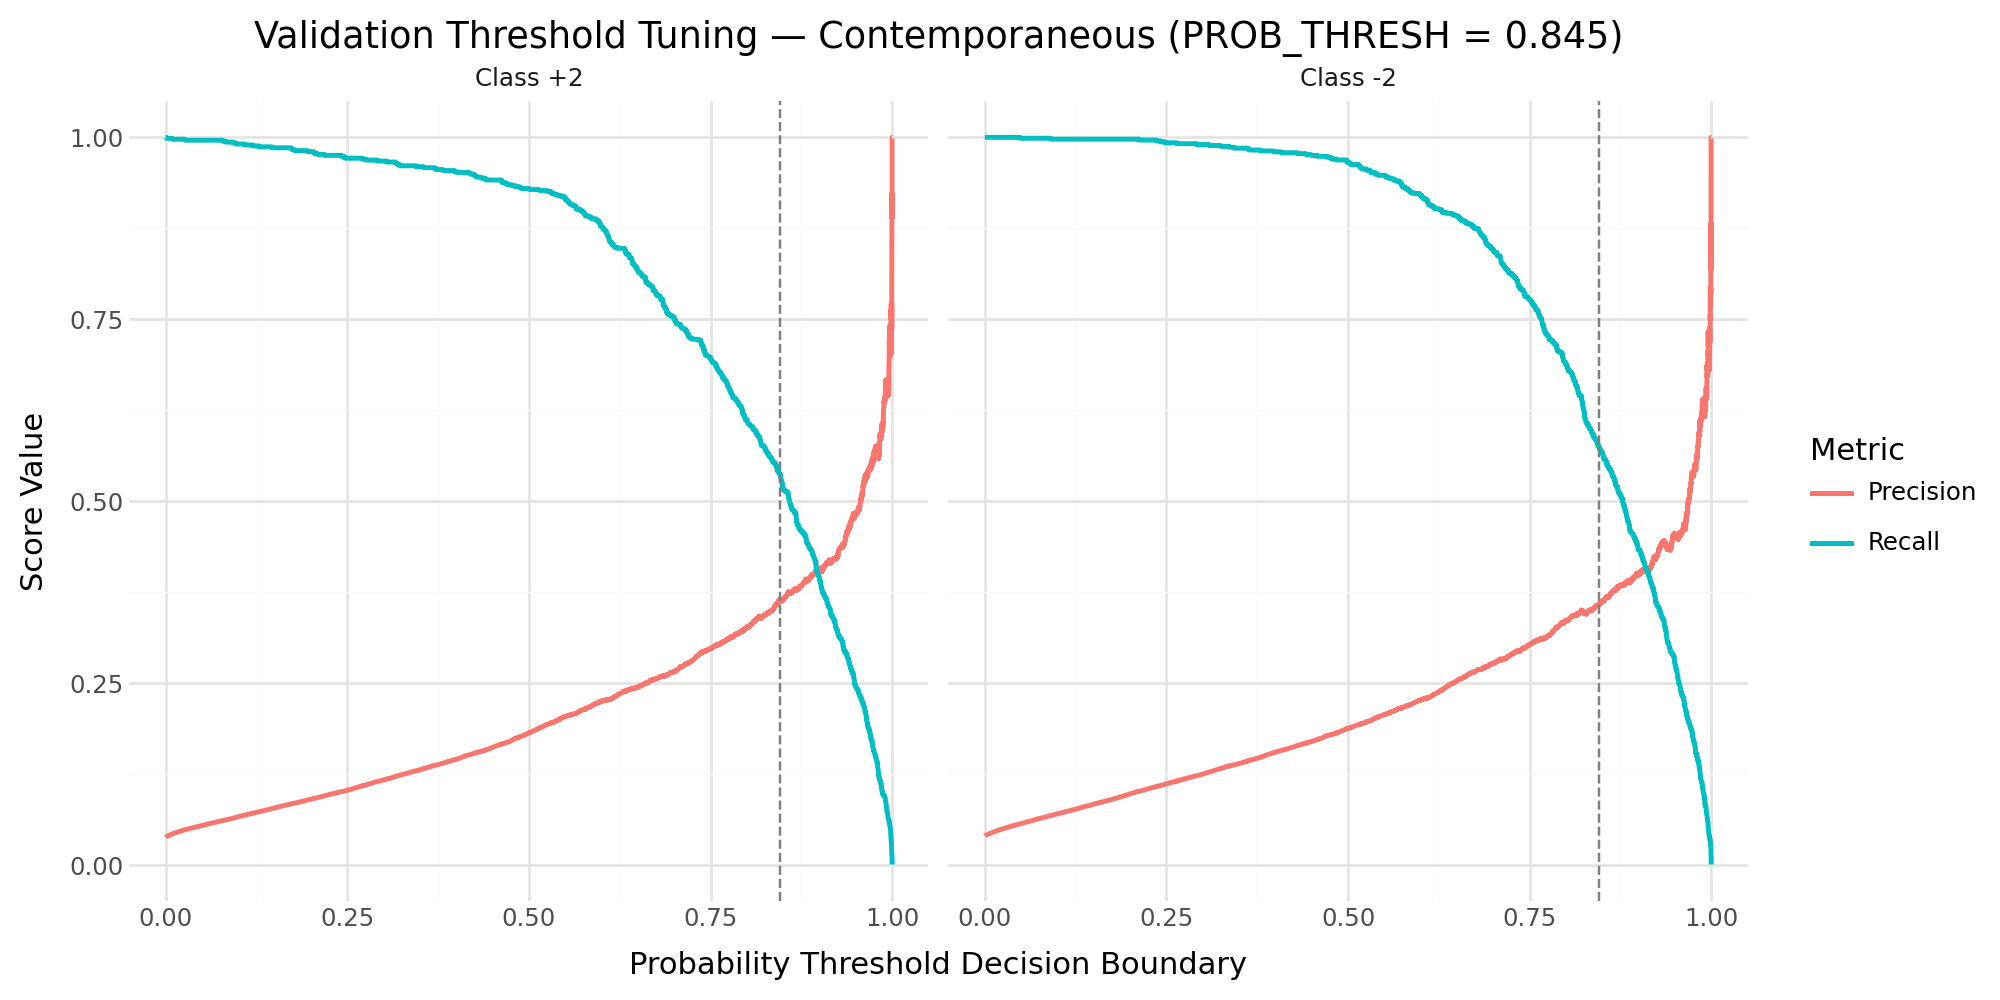

In [36]:
# --- Tune the decision threshold on VALIDATION (2024) -----------------------
# Sweep the tail-vs-majority boundary to maximise macro-F1; compare to naive arg-max-prob.
y_val_c, probs_val_c = data_contemp['val']

PROB_THRESH, best_f1_c, sweep_c = tune_threshold(y_val_c, probs_val_c)
argmax_f1_c = f1_score(y_val_c, np.array(CATS)[probs_val_c.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal PROB_THRESH = {PROB_THRESH:.3f}  '
      f'(val macro-F1 = {best_f1_c:.4f}  vs  arg-max-prob = {argmax_f1_c:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_c = pr_threshold_df(y_val_c, probs_val_c)
(
    ggplot(pr_long_c, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=PROB_THRESH, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Contemporaneous (PROB_THRESH = {PROB_THRESH:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Contemporaneous | train (2021-2023) | thr=0.845 | accuracy=0.8551 | n=64,211 ---
              precision    recall  f1-score   support

          -2       0.51      0.42      0.46      4523
           0       0.91      0.93      0.92     55038
          +2       0.47      0.44      0.46      4650

    accuracy                           0.86     64211
   macro avg       0.63      0.60      0.61     64211
weighted avg       0.85      0.86      0.85     64211


--- Contemporaneous | val (2024) | thr=0.845 | accuracy=0.8869 | n=19,873 ---
              precision    recall  f1-score   support

          -2       0.36      0.58      0.44       805
           0       0.96      0.92      0.94     18300
          +2       0.36      0.54      0.43       768

    accuracy                           0.89     19873
   macro avg       0.56      0.68      0.60     19873
weighted avg       0.91      0.89      0.90     19873


--- Contemporaneous | test (2025) | thr=0.845 | accuracy=0.8867 | n=20,3

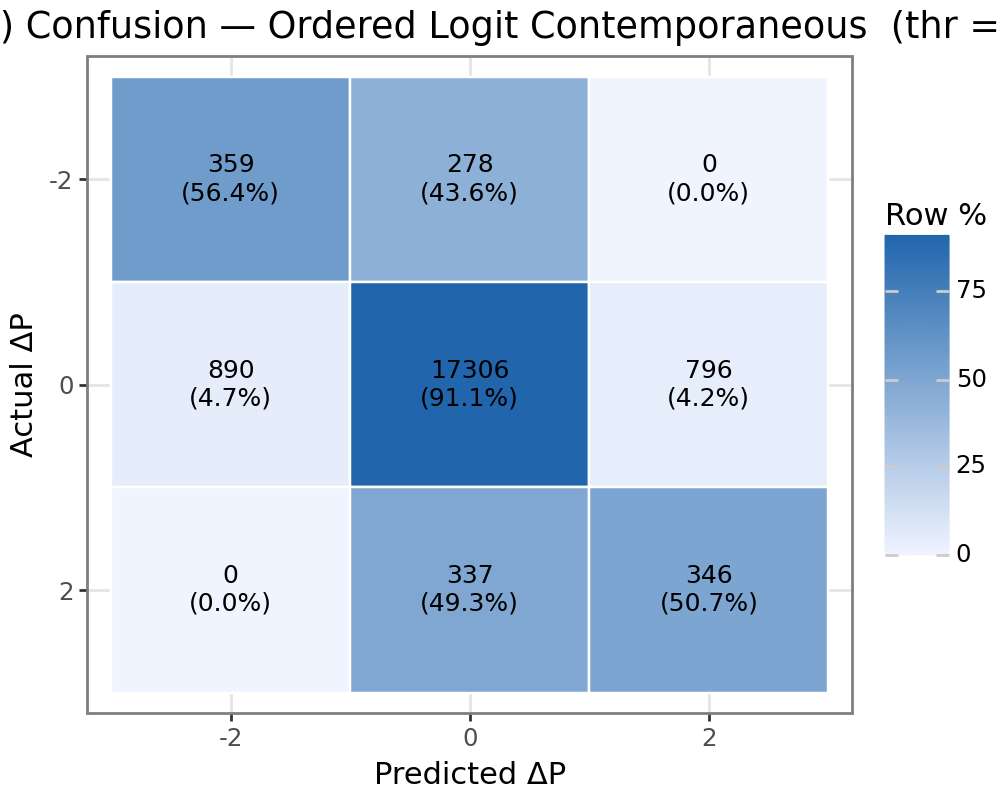

In [37]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
# Train / val / test classification reports at the SAME validation-selected PROB_THRESH,
# then the held-out 2025 confusion matrix (raw counts + row %).
report_all_splits(data_contemp, PROB_THRESH, 'Contemporaneous')

y_test_c, probs_test_c = data_contemp['test']
confusion_tile(
    y_test_c, assign_classes(probs_test_c, PROB_THRESH),
    title=f'Test (2025) Confusion — Ordered Logit Contemporaneous  (thr = {PROB_THRESH:.3f})',
)

## Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical class-weighted ordered logit, but the target is $\Delta P_{t+1}$ — the next bin's
**cleaned** price change, shifted into the current row with `.shift(-1).over(['security', 'date'])`
in the cleaning step (before the split), so there is no look-ahead leakage across sessions or
years. Trained on 2021-2023, threshold tuned on validation (2024), evaluated on test (2025).

In [38]:
# --- Predictive 1-step-ahead: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Target delta_p_fwd = next bin's cleaned delta_p, built within each [security, date] session
# in the cleaning cell (before the split) — no look-ahead across sessions or year boundaries.
res_fwd, data_fwd = fit_weighted_olr('delta_p_fwd', TC_FEATURES, 'Predictive 1-step (tick-constrained)')

=== Predictive 1-step (tick-constrained):  delta_p_fwd ~ obi + noi + stv  (train 2021-2023, n=63,609) ===
train class counts: {-2: 4490, 0: 54509, 2: 4610}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.2973e+05
Model:             WeightedOrderedModel   AIC:                         2.595e+05
Method:              Maximum Likelihood   BIC:                         2.595e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          14:00:24                                         
No. Observations:                 63609                                         
Df Residuals:                     63604                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

Validation-optimal THRESH_FWD = 0.745  (val macro-F1 = 0.6006  vs  arg-max-prob = 0.4019)


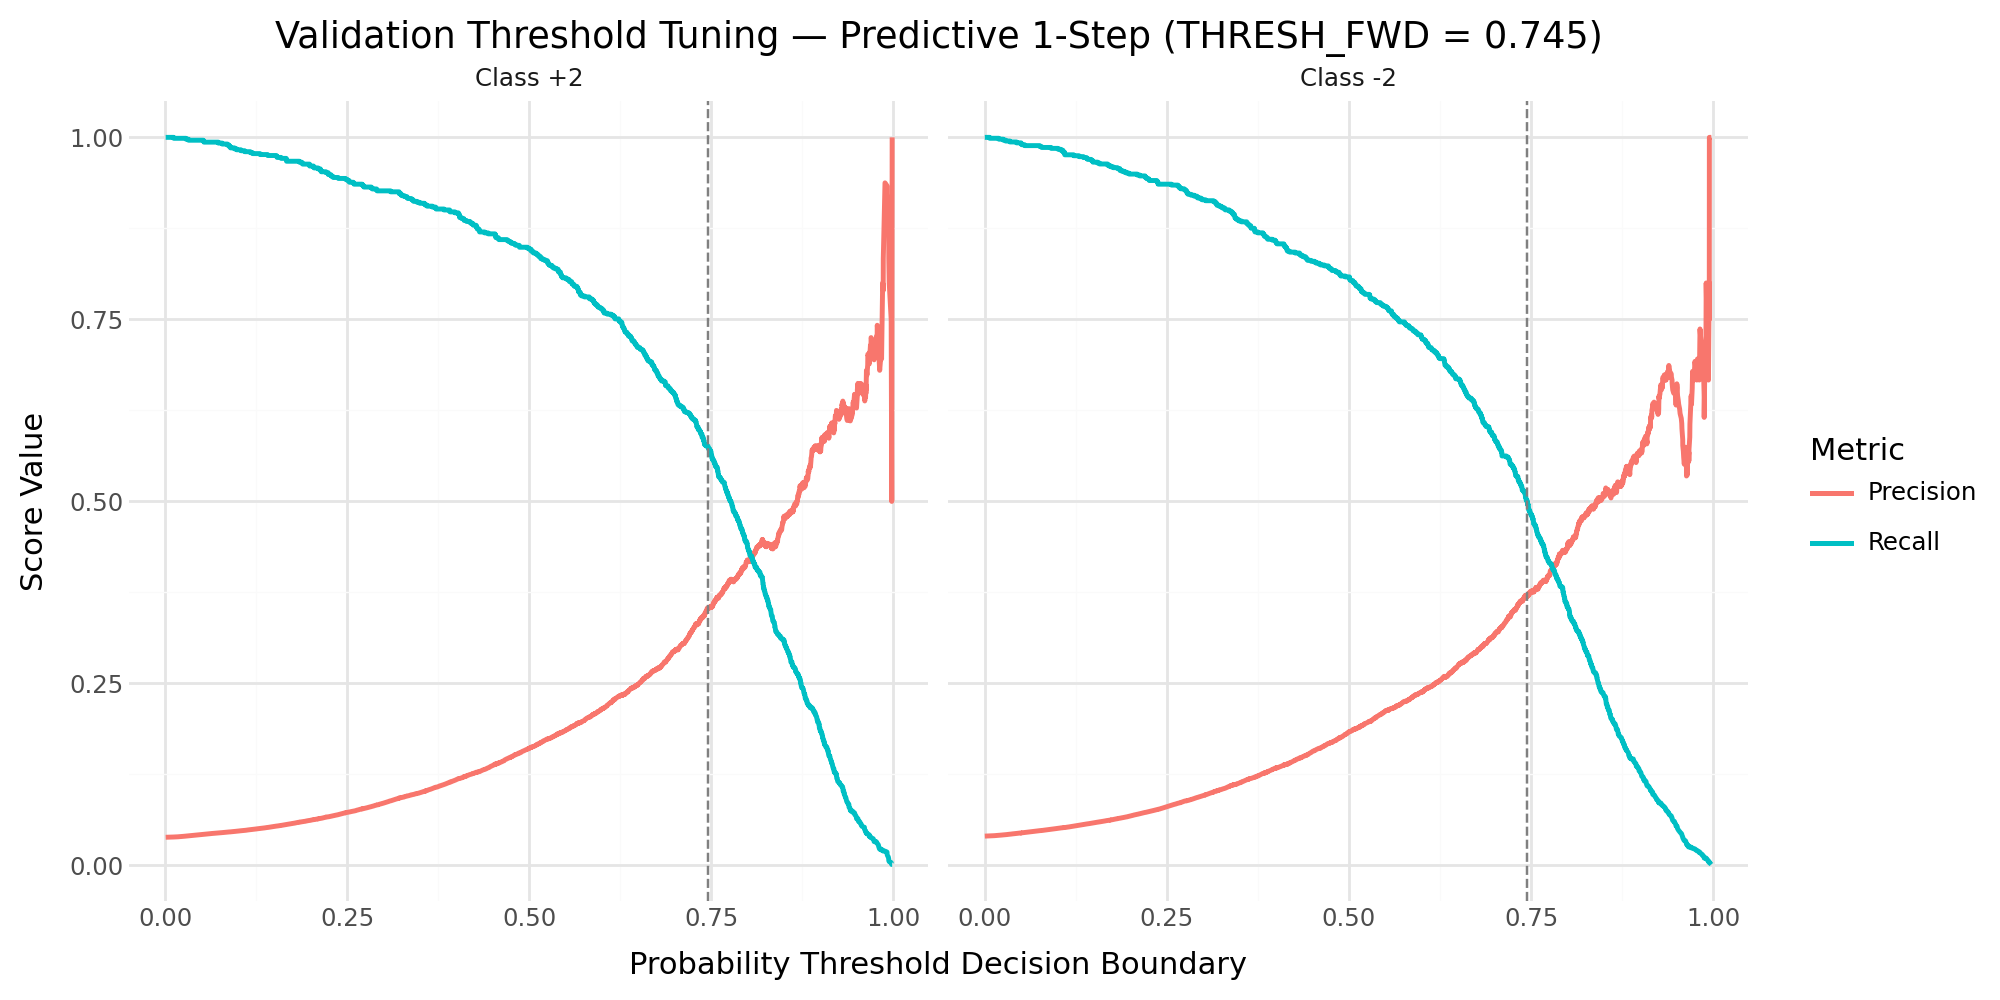

In [39]:
# --- Tune the predictive decision threshold on VALIDATION (2024) ------------
y_val_f, probs_val_f = data_fwd['val']

THRESH_FWD, best_f1_f, sweep_f = tune_threshold(y_val_f, probs_val_f)
argmax_f1_f = f1_score(y_val_f, np.array(CATS)[probs_val_f.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal THRESH_FWD = {THRESH_FWD:.3f}  '
      f'(val macro-F1 = {best_f1_f:.4f}  vs  arg-max-prob = {argmax_f1_f:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_f = pr_threshold_df(y_val_f, probs_val_f)
(
    ggplot(pr_long_f, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=THRESH_FWD, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step (THRESH_FWD = {THRESH_FWD:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step | train (2021-2023) | thr=0.745 | accuracy=0.8271 | n=63,609 ---
              precision    recall  f1-score   support

          -2       0.36      0.34      0.35      4490
           0       0.89      0.91      0.90     54509
          +2       0.39      0.35      0.37      4610

    accuracy                           0.83     63609
   macro avg       0.55      0.53      0.54     63609
weighted avg       0.82      0.83      0.82     63609


--- Predictive 1-step | val (2024) | thr=0.745 | accuracy=0.8888 | n=19,684 ---
              precision    recall  f1-score   support

          -2       0.37      0.50      0.42       793
           0       0.96      0.92      0.94     18129
          +2       0.35      0.58      0.44       762

    accuracy                           0.89     19684
   macro avg       0.56      0.66      0.60     19684
weighted avg       0.91      0.89      0.90     19684


--- Predictive 1-step | test (2025) | thr=0.745 | accuracy=0.8879 | 

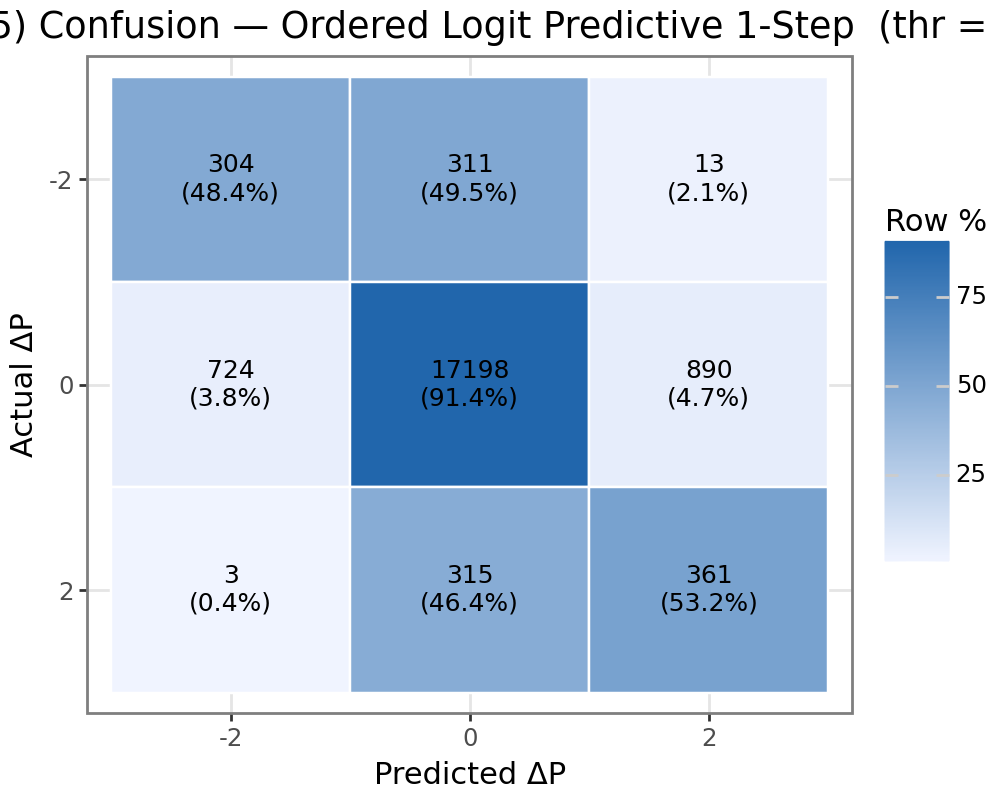

In [40]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
report_all_splits(data_fwd, THRESH_FWD, 'Predictive 1-step')

y_test_f, probs_test_f = data_fwd['test']
confusion_tile(
    y_test_f, assign_classes(probs_test_f, THRESH_FWD),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step  (thr = {THRESH_FWD:.3f})',
)